In [1]:
import os
import random
import numpy as np
import pandas as pd
import time
from matplotlib import pyplot as plt

In [2]:
np.random.seed(42)

### **Treatment-induced system dynamics**

In [3]:
# system parameters for training
gamma = 0.08
m1 = 0.00005
c1 = 1; c2 = 1; k1 = 0; k2 = 2; k3 = 8; k4 = 0.5

# UNCOMMENT TO USE

# Bone
# alpha1 = 0.0204; alpha2 = 0.0242; beta1 = 0.0076; beta2 = 0.0168

# Lymph Node
alpha1 = 0.0290; alpha2 = 0.0277; beta1 = 0.0085; beta2 = 0.0222

In [4]:
# A = [a0]; X1 = [x10]; X2 = [x20]; Y = [c1*X1[0]+c2*X2[0]]; dY = []
# P1 = [A[0]/(A[0]+k2)]; Q1 = [k3+(1-k3)*(A[0]/(A[0]+k4))]; P2 = [1-A[0]/A[0]]; Q2 = [1]; M = [m1*(1-(A[0]/A[0]))]

In [5]:
def On_Treatment(A, X1, X2, Y, dY, Week, a0):
    '''
    a, x1, x2, y, p1, q1, p2, q2, m: lists of the variable values over time
    Week: time of observation that starts to accumulate at the beginning of the simulation
    '''
    # iteration paramters
    h = 2                      # step length
    Starting_Time = Week*7
    Ending_Time = (Week+1)*7   # (e.g. week 0 -> i will loop for 7 days)
    
    for t in range(Starting_Time, Ending_Time):
        a_tplus1 = (-gamma*(A[t]-a0)-gamma*a0*1)*h+A[t] # u(t)=1, on-treatment
        A.append(a_tplus1)

        p1_t = k1+(1-k1)*(A[t+1]/(A[t+1]+k2))
        q1_t = k3+(1-k3)*(A[t+1]/(A[t+1]+k4))
        p2_t = 1-(A[t+1]/a0)
        q2_t = 1
        m_t = m1*(1-(A[t+1]/a0))
        
        x1_tplus1 = ((alpha1*p1_t-beta1*q1_t-m_t)*X1[t])*h+X1[t]; X1.append(x1_tplus1)
        x2_tplus1 = (m_t*X1[t]+(alpha2*p2_t-beta2*q2_t)*X2[t])*h+X2[t]; X2.append(x2_tplus1)

        dy_t = c1*((alpha1*p1_t-beta1*q1_t-m_t)*X1[t+1]) + c2*(m_t*X1[t+1]+(alpha2*p2_t-beta2*q2_t)*X2[t+1])
        dY.append(dy_t)
        
        y_tplus1 = c1*X1[t+1]+c2*X2[t+1]
        Y.append(y_tplus1)

    return A, X1, X2, Y, dY

In [6]:
def Off_Treatment(A, X1, X2, Y, dY, Week, A0):
    '''
    a, x1, x2, y, p1, q1, p2, q2, m: lists of the variable values over time
    Week: time of observation that starts to accumulate at the beginning of the simulation
    '''
    # iteration paramters 
    h = 2
    Starting_Time = Week*7
    Ending_Time = (Week+1)*7
    
    for t in range(Starting_Time, Ending_Time):
        a_tplus1 = (-gamma*(A[t]-a0)-gamma*a0*0)*h+A[t] # u(t)=0, off-treatment
        A.append(a_tplus1)

        p1_t = k1+(1-k1)*(A[t+1]/(A[t+1]+k2))
        q1_t = k3+(1-k3)*(A[t+1]/(A[t+1]+k4))
        p2_t = 1-(A[t+1]/a0)
        q2_t = 1
        m_t = m1*(1-(A[t+1]/a0))
        
        x1_tplus1 = ((alpha1*p1_t-beta1*q1_t-m_t)*X1[t])*h+X1[t]; X1.append(x1_tplus1)
        x2_tplus1 = (m_t*X1[t]+(alpha2*p2_t-beta2*q2_t)*X2[t])*h+X2[t]; X2.append(x2_tplus1)

        dy_t = c1*((alpha1*p1_t-beta1*q1_t-m_t)*X1[t+1]) + c2*(m_t*X1[t+1]+(alpha2*p2_t-beta2*q2_t)*X2[t+1])
        dY.append(dy_t)
        
        y_tplus1 = c1*X1[t+1]+c2*X2[t+1]
        Y.append(y_tplus1)

    return A, X1, X2, Y, dY

### **Q-Learning**

In [7]:
# q_table_file = r'C:\Users\amp87\Desktop\QLearning\QLearning\q_table.csv'

N_STATES = 4*12*5*4    # 4 weeks/month * 12 months/year * 5 years * 4 ordinal data (high, medium, proper, low)
EPSILON = 1.0          # init value, < EPSILON then greedy
EPSILON_decay = 0.999  # decay factor, < EPSILON then greedy (allows the random exploring)
ALPHA = 0.05           # learning rate
GAMMA = 0.9            # discount factor

MAX_EPISODES = 15000   # maximum training episodes
Y_UPPER = 10           # serum PSA concentration y(t)'s upper bound, threshold for biomedical recurrence (unit: ng/10mL)
# Y_LOWER = 1          # y(t) lower bound
INIT = [30, 15, 0.01]  # initial conditions
a0 = 30                # a0

ACTIONS = ['med', 'non_med']  # possible actions, medication (on), non-medication (off)

In [8]:
# a0 = INIT[0]; x10 = INIT[1]; x20 = INIT[2]
# A = [a0]; X1 = [x10]; X2 = [x20]; Y = [c1*X1[0]+c2*X2[0]]; dY = []

# P1 = [A[0]/(A[0]+k2)]; Q1 = [k3+(1-k3)*(A[0]/(A[0]+k4))]; P2 = [1-A[0]/A[0]]; Q2 = [1]; M = [m1*(1-(A[0]/A[0]))]

In [9]:
def decode_state(state_index):
    ordinal = state_index % 4           # Ordinal (0: low, 1: proper, 2: medium, 3: high)
    week = (state_index//4) % 4         # Week    (0 to 3 within a month)
    month = (state_index//(4*4)) % 12   # Month   (0 to 11 within a year)
    year = state_index // (4*4*12)      # Year    (0 to 4 within 5 years)
    return year, month, week, ordinal
    
def is_terminal_state(state_index):
    year, month, week, _ = decode_state(state_index)
    return year == 4 and month == 11 and week == 3

##### **Q-Table**

In [10]:
# initialie the Q-table (or use an existing one)

Q_table_file = '/Users/ekeulseuji/Downloads/Q_table_Case3.csv'

def build_q_table(n_States, Actions):
    '''
    if os.path.exists('/Users/ekeulseuji/Downloads/Q_table.csv'):
        Table = pd.read_csv(Q_table_file)
    else: 
        Table = pd.DataFrame(np.zeros((n_States, len(Actions))), 
                             columns = Actions)
    '''
    Table = pd.DataFrame(np.zeros((n_States, len(Actions))), columns = Actions)
    return Table

##### **Action**

In [11]:
def choose_action(State, Q_table, EPSILON_n_iter):
    State_Actions = Q_table.iloc[State, :]  # all posible actions at the current (input) state

    # non-greedy, or the state hasn't been explored yet -> act randomly
    if (np.random.uniform() < EPSILON*(EPSILON_decay**EPSILON_n_iter)) or (State_Actions.all() == 0):  
        Action_SELECTED = np.random.choice(ACTIONS)
    else:
        if np.random.uniform() < 0.999:
            Action_SELECTED = State_Actions.idxmax()  # acts greedy
        else:
            Action_SELECTED = np.random.choice(ACTIONS)
    
    return Action_SELECTED, EPSILON_n_iter

In [12]:
def choose_best_action(State, Q_table):
    State_Actions = Q_table.iloc[State, :]  # all posible actions at the current (input) state
    Action_SELECTED = State_Actions.idxmax()  # acts greedy
    return Action_SELECTED

##### **State**

In [13]:
# helper function to categorize serum PSA levels (y_t) into ordinal categories
def y_to_scope(y_t):
    '''
    returns the scope: Ordinal category (0: low, 1: proper, 2: medium, 3: high)
    '''
    if 0 <= y_t < 10:
        scope = 0  # Low
    elif 10 <= y_t < 20:
        scope = 1  # Proper
    elif 20 <= y_t < 30:
        scope = 2  # Medium
    elif 30 <= y_t:
        scope = 3  # High

    return scope

In [14]:
# helper function to check whether the list has any element >= the upper threhold
def check_biomedical_progression(in_PSA_list, in_deriv_PSA):
    """
    progression: serum PSA level > 10 ng/mL and dY > 0.1 for 3 consecutive weeks (21 days)
    """
    # <21 days
    if len(in_PSA_list) < 21:
        return False
        
    else:  
        biom_rec = True
        for day in range(len(in_PSA_list)-22, len(in_PSA_list)-1):
            if in_PSA_list[day] <= Y_UPPER or in_deriv_PSA[day] <= 0.1:
                biom_rec = False
        return biom_rec

In [15]:
# determine the new state (New_State) and immediate reward (Reward) of an agent after taking an action
def get_env_feedback(Current_State, Action, Week, A, X1, X2, Y, dY):
    '''
    do switching, check med-/no med-induced dynamics 
    Current_State: current dyn.
    Action: 'med' or 'non_med'
    Week: current week
    A, X1, X2, Y, dY: lists containing the past cond.s
    '''
    if Action == 'med':
        A, X1, X2, Y, dY = On_Treatment(A, X1, X2, Y, dY, Week, a0)
        action_cost = -5  # med
    else:
        A, X1, X2, Y, dY = Off_Treatment(A, X1, X2, Y, dY, Week, a0)
        action_cost = 0   # no med

    Current_y = Y[-1]                  # the current serum PSA level at the end of the week
    PSA_scope = y_to_scope(Current_y)  # action induced PSA level (0: low, 1: proper, 2: medium, 3: high)
    
    # biochemical reccurrence?
    is_rec = check_biomedical_progression(Y, dY)
    
    # check terminal condition: environment ends when the state corresponds to the last time step (end of 5 years, i.e., week 240)
    is_finished = (Week >= (N_STATES // 4) - 1)

    if is_rec:
        New_State = -1
        Reward = -100
    elif is_finished:
        New_State = -1
        Reward = 100   # successful long-living rewards: recurrence-free survival(RFS), reaches the terminal
    else:
        # N_STATES: [Year][Month][Week][Ordinal] -> 4 * 12 * 5 * 4
        next_week_base = (Week + 1) * 4
        New_State = next_week_base + PSA_scope
        
        # interm. rewards: low PSA, med withdraw
        Reward = action_cost + (2-PSA_scope)

    return New_State, Reward, A, X1, X2, Y, dY

##### **How the strategy looks**

In [16]:
# result (figure) showing how the agent interacts with the environment
def update_env(Y, Strating_Time):
    # a list of time points corresponding to days for figure drawing (7, 14, 21, 28, 35, ...) # seven days a week
    Days_in_Weeks = [i*7 for i in range(1, int(N_STATES/7))]

    # match the length for Days_in_Weeks and Y
    for j in range(int(N_STATES/7)-len(Y)):
        Y.append(0)

    # clear current figure
    plt.clf()  
    plt.title('Bone metastasis')
    plt.plot(Days_in_Weeks, Y, label='last T = {}'.format(Starting_Time*7))
    plt.ylim(0, 100)
    plt.ylabel('Serum PSA')
    plt.xlabel('Time')
    plt.legend(loc='lower right')
    # plt.savefig('figure.png', dpi=300)
    plt.show()

### **The Main QL Algorithm**

In [17]:
Training_Mode = True

In [18]:
best_Q_tables = []

In [19]:
def RL_training_process():
    # build (initialize) the Q table
    Q_table = build_q_table(N_STATES, ACTIONS) 

    # save the best Q table
    best_Q_score = -np.inf
    best_Q = None

    EPSILON_n_iter = 0
    
    for episode in range(MAX_EPISODES):
        # init env
        Week = 0
        EPSILON_n_iter = EPSILON_n_iter + 1 # starts the decay for every training iteration
        terminate = False
        
        # init lists
        a_init = INIT[0]; x1_init = INIT[1]; x2_init = INIT[2]
        A, X1, X2 = [a_init], [x1_init], [x2_init]
        Y = [c1*X1[0] + c2*X2[0]]
        dY = []
        Action_List_QL = []
        med_punishment = 0
        
        Current_State = y_to_scope(Y[0]) # init states (0-3)

        while not terminate:
            Current_Action, EPSILON_n_iter = choose_action(Current_State, Q_table, EPSILON_n_iter)
            Action_List_QL.extend([Current_Action]*7)
            if Current_Action == 'med':
                med_punishment = med_punishment + 1
            
            # interact with the env
            New_State, Reward, A, X1, X2, Y, dY = get_env_feedback(Current_State, Current_Action, Week, A, X1, X2, Y, dY)
            
            # update Q-table
            Q_val_predict = Q_table.loc[Current_State, Current_Action]
            
            if New_State != -1:
                Q_val_target = Reward + GAMMA * Q_table.iloc[New_State, :].max()
            else:
                Q_val_target = Reward
                terminate = True
                if episode%1000 == 0: # if Week > 150: # great Episodes
                    print(f'Episode: {episode} | Weeks Survived: {Week+1} | Final PSA: {Y[-1]:.2f}')
                if Week >= 239:
                    best_Q_tables.append({"weeks": Week, "psa": Y, "Q_tab": Q_table,
                                          "act_list": Action_List_QL,
                                          "med_puni": med_punishment})
                

            Q_table.loc[Current_State, Current_Action] += ALPHA * (Q_val_target - Q_val_predict)
            
            # state shift
            Current_State = New_State
            Week += 1
            
            # cool
            if Week >= (N_STATES // 4):
                terminate = True

        if episode%7500 == 0:
            Y_index = [i for i in range(len(Y))]

            plt.figure(figsize=(40,5))
            plt.plot(Y_index, Y, label='y(t)', color=(100/255, 10/255, 10/255, 0.75), linewidth=1.5, linestyle='-')

            plt.grid(True)
            plt.xlabel('Time')
            plt.ylabel('Serum PSA (ng/mL)')
            plt.title('Serum PSA Level Over Time (Q-Learning)\n')
            plt.show()

            A_index = 0
            shadow_segments = []

            plt.figure(figsize=(40,5))

            for act in Action_List_QL:
                if act == 'med':
                    plt.plot([A_index, A_index+1], [1,1], color='black', linewidth=1.5)
                    shadow_segments.append((A_index, A_index+1))
                elif act == 'non_med':
                    plt.plot([A_index, A_index+1], [0,0], color='black', linewidth=1.5)
                A_index = A_index + 1

            for start, end in shadow_segments:
                plt.fill_between([start, end], 0, 1, color='m', alpha=0.1)

            plt.grid(True)
            plt.xlabel('Time')
            plt.ylabel('Action')
            plt.title('Actions Over Time (Q-Learning)\n')
            plt.show()

    print(len(best_Q_tables))
    df = pd.DataFrame(best_Q_tables)

    lowest_med_punishment = np.inf
    best_of_the_bests = None

    for idx, row in df.iterrows():
        if row['med_puni'] < lowest_med_punishment: # choose the one with the best medication strategy
            best_of_the_bests = row

    best_Q_table = best_of_the_bests["Q_tab"]
    best_PSA_ctrl = best_of_the_bests["psa"]
    best_Act_list = best_of_the_bests["act_list"]

    best_Q_table.to_csv(Q_table_file, index=False)

    return best_Q_table, best_PSA_ctrl, best_Act_list

Episode: 0 | Weeks Survived: 3 | Final PSA: 27.71


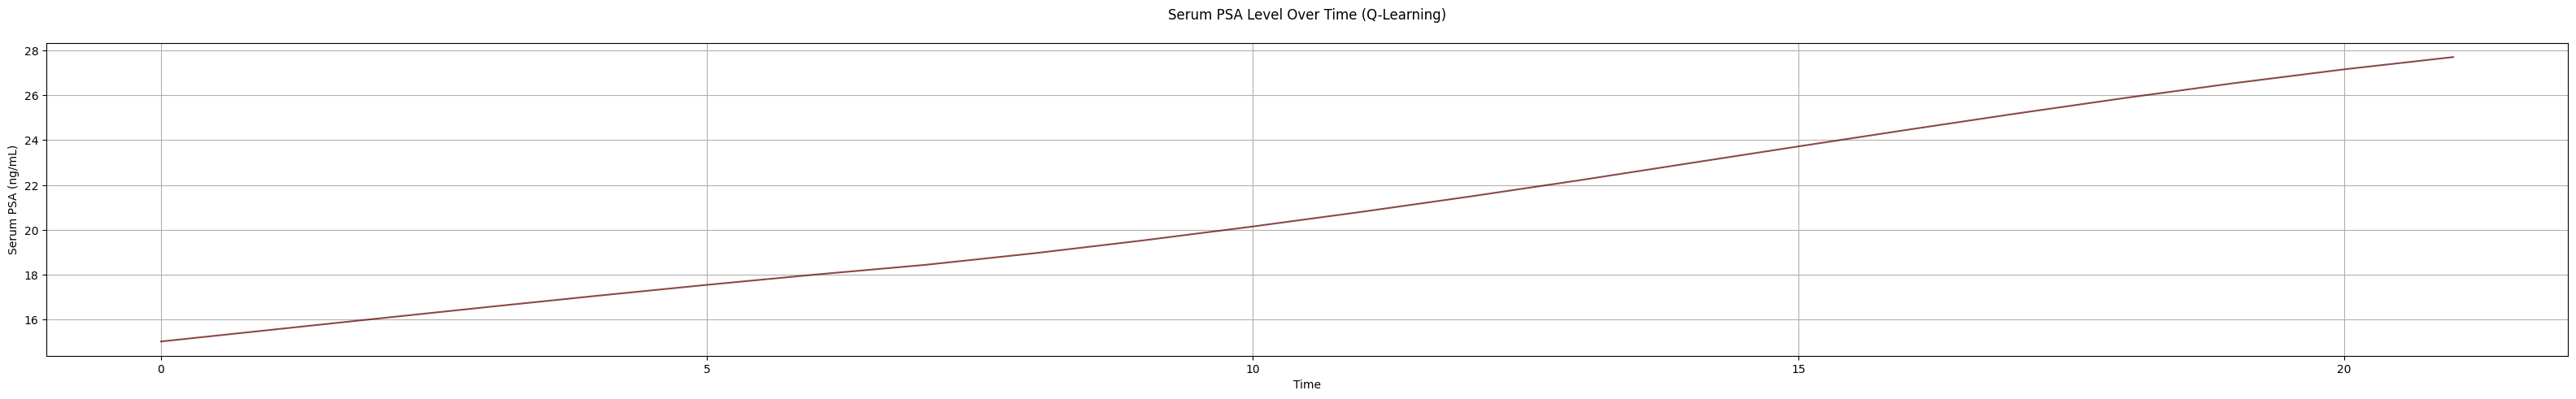

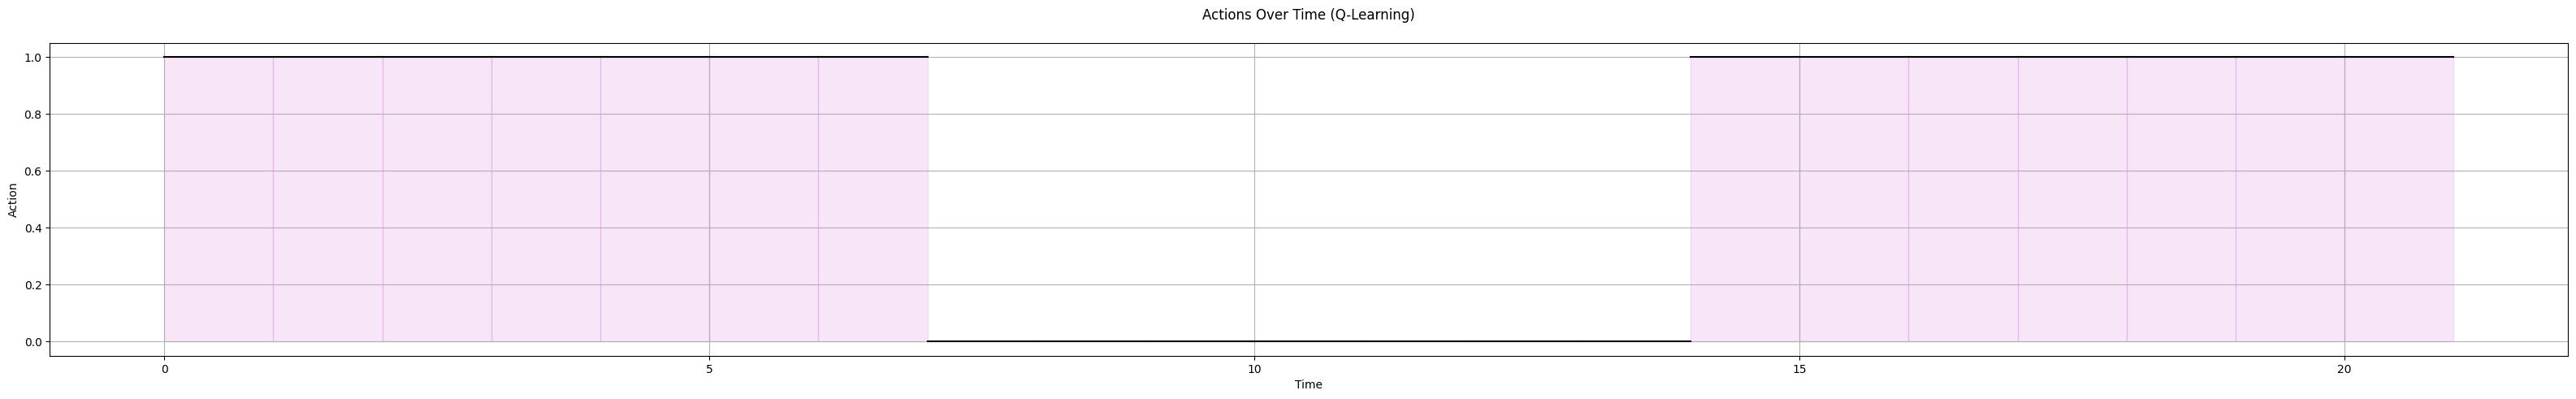

Episode: 1000 | Weeks Survived: 12 | Final PSA: 19.09
Episode: 2000 | Weeks Survived: 20 | Final PSA: 19.68
Episode: 3000 | Weeks Survived: 20 | Final PSA: 24.19
Episode: 4000 | Weeks Survived: 47 | Final PSA: 41.21
Episode: 5000 | Weeks Survived: 34 | Final PSA: 26.74
Episode: 6000 | Weeks Survived: 3 | Final PSA: 30.00
Episode: 7000 | Weeks Survived: 124 | Final PSA: 19.52


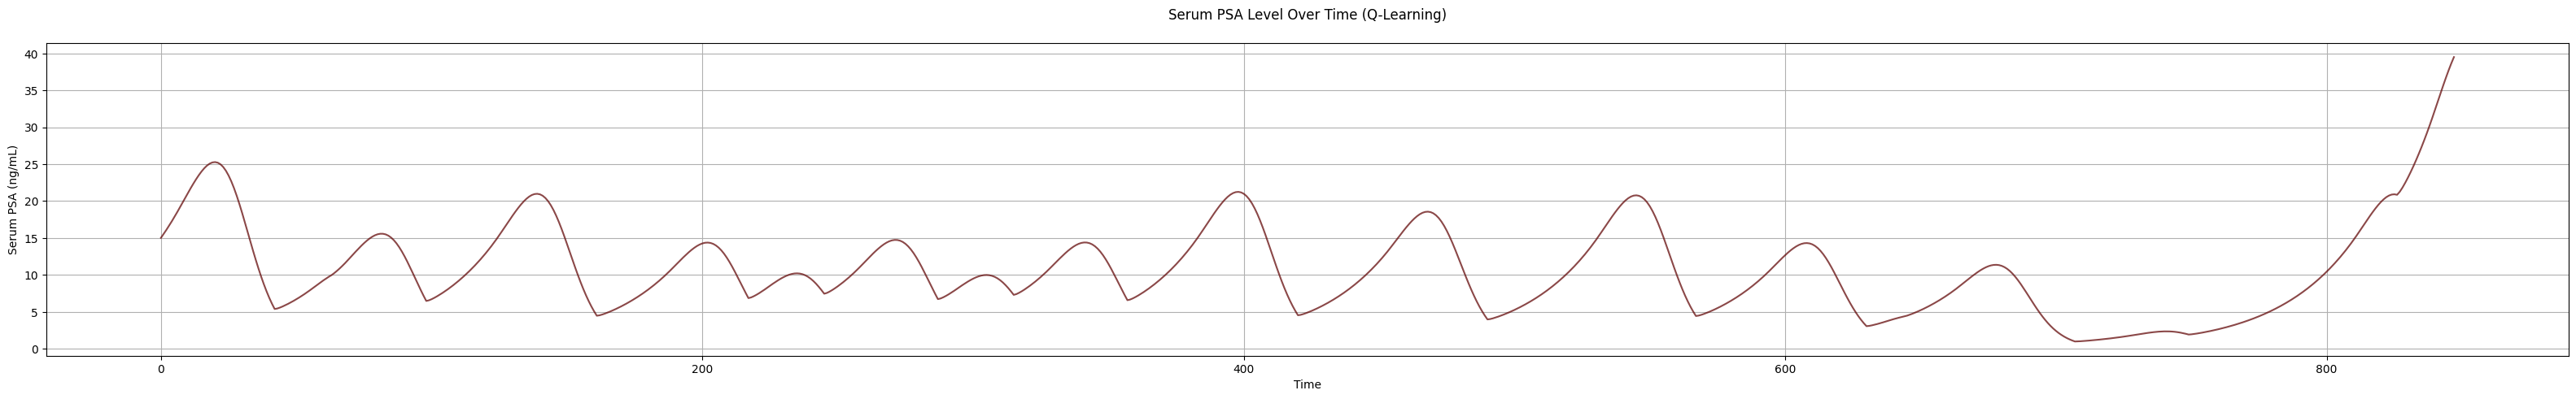

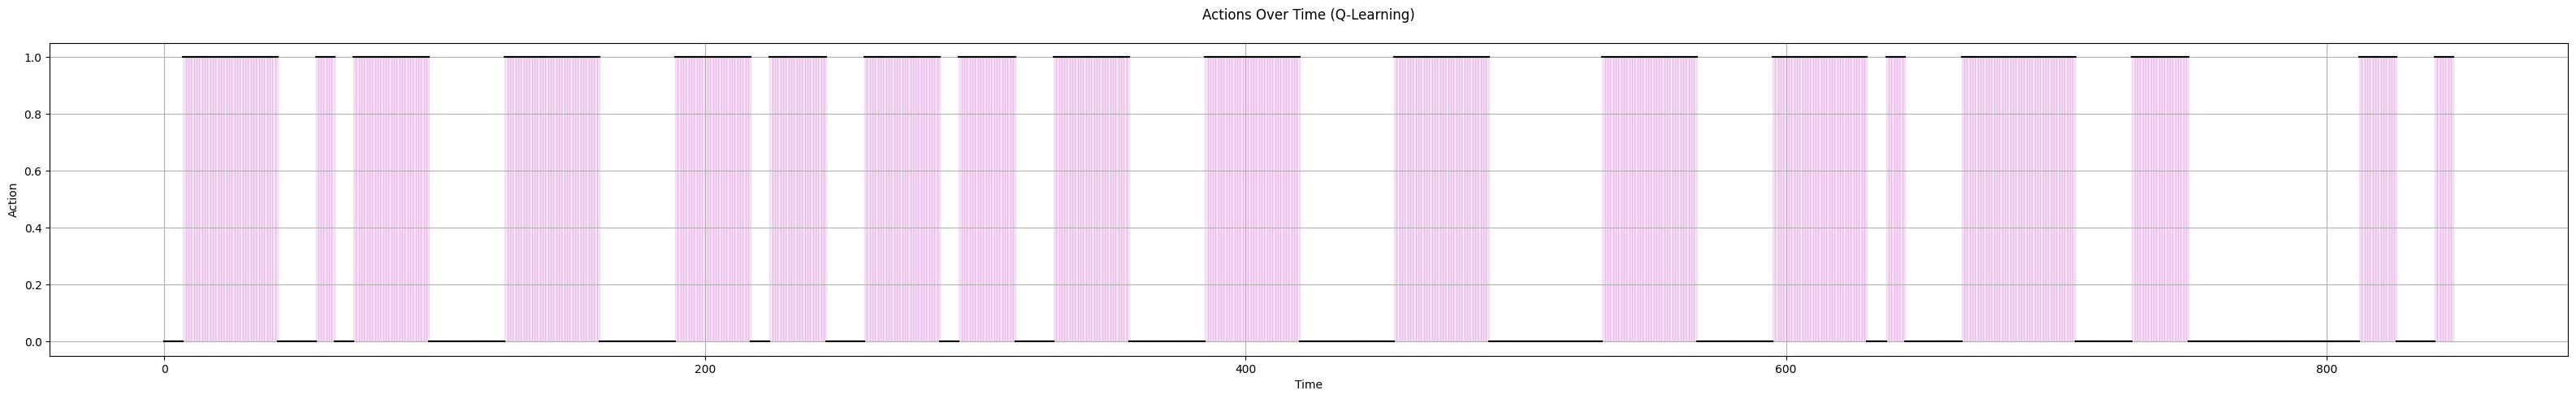

Episode: 8000 | Weeks Survived: 54 | Final PSA: 137.58
Episode: 9000 | Weeks Survived: 196 | Final PSA: 47.27
Episode: 10000 | Weeks Survived: 235 | Final PSA: 29.69
Episode: 11000 | Weeks Survived: 240 | Final PSA: 20.21
Episode: 12000 | Weeks Survived: 134 | Final PSA: 20.40
Episode: 13000 | Weeks Survived: 122 | Final PSA: 19.71
Episode: 14000 | Weeks Survived: 190 | Final PSA: 20.34
1238


In [20]:
final_Q_table = None

if Training_Mode == True:
    Q_table, PSA_List, Action_list_QL = RL_training_process()
    final_Q_table = Q_table
else:
    final_Q_table = pd.read_csv(Q_table_file)

### **Final Performances**

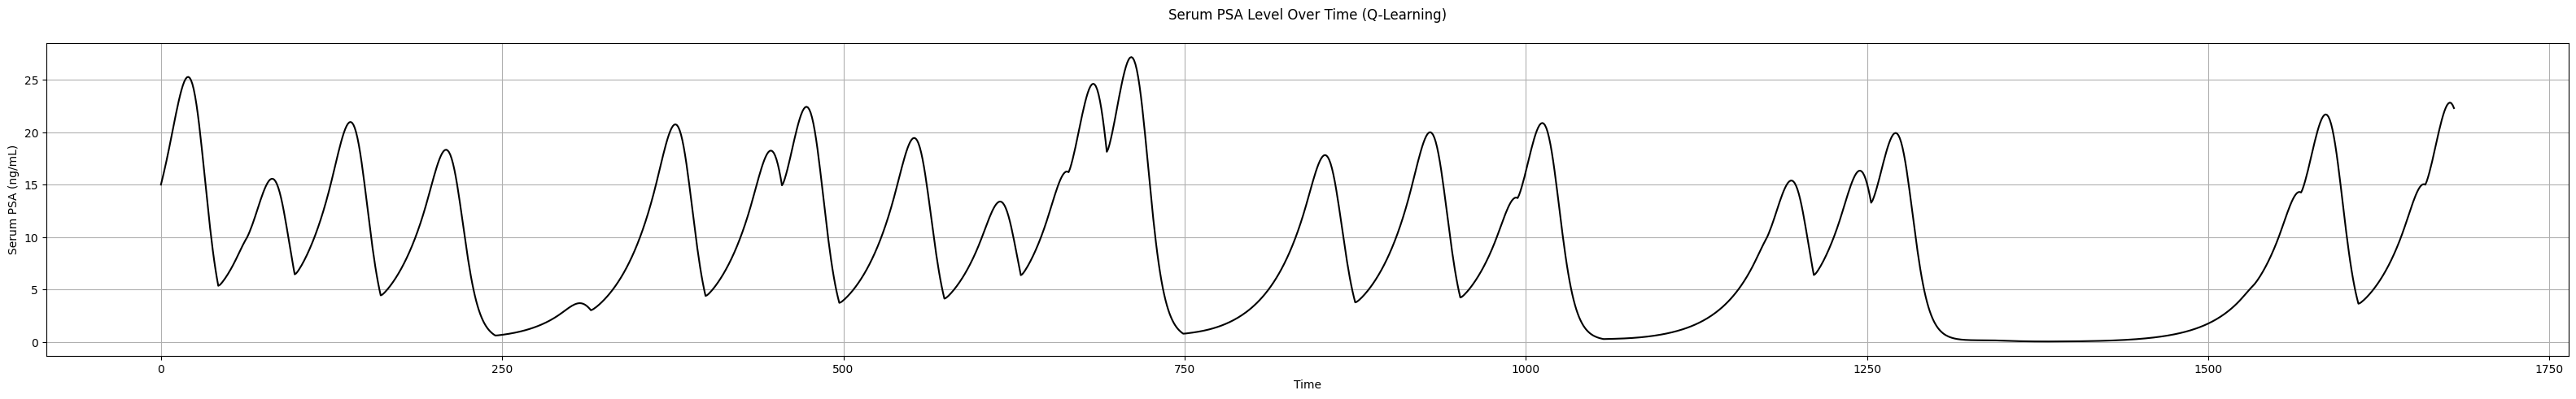

In [21]:
Y_index = [i for i in range(len(PSA_List))]

plt.figure(figsize=(40,5))
plt.plot(Y_index, PSA_List, label='y(t)', color='black', linewidth=1.5, linestyle='-')

plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Serum PSA (ng/mL)')
plt.title('Serum PSA Level Over Time (Q-Learning)\n')

plt.savefig('/Users/ekeulseuji/Downloads/Serum_PSA_QL_C3.png', dpi=600, bbox_inches='tight')
plt.show()

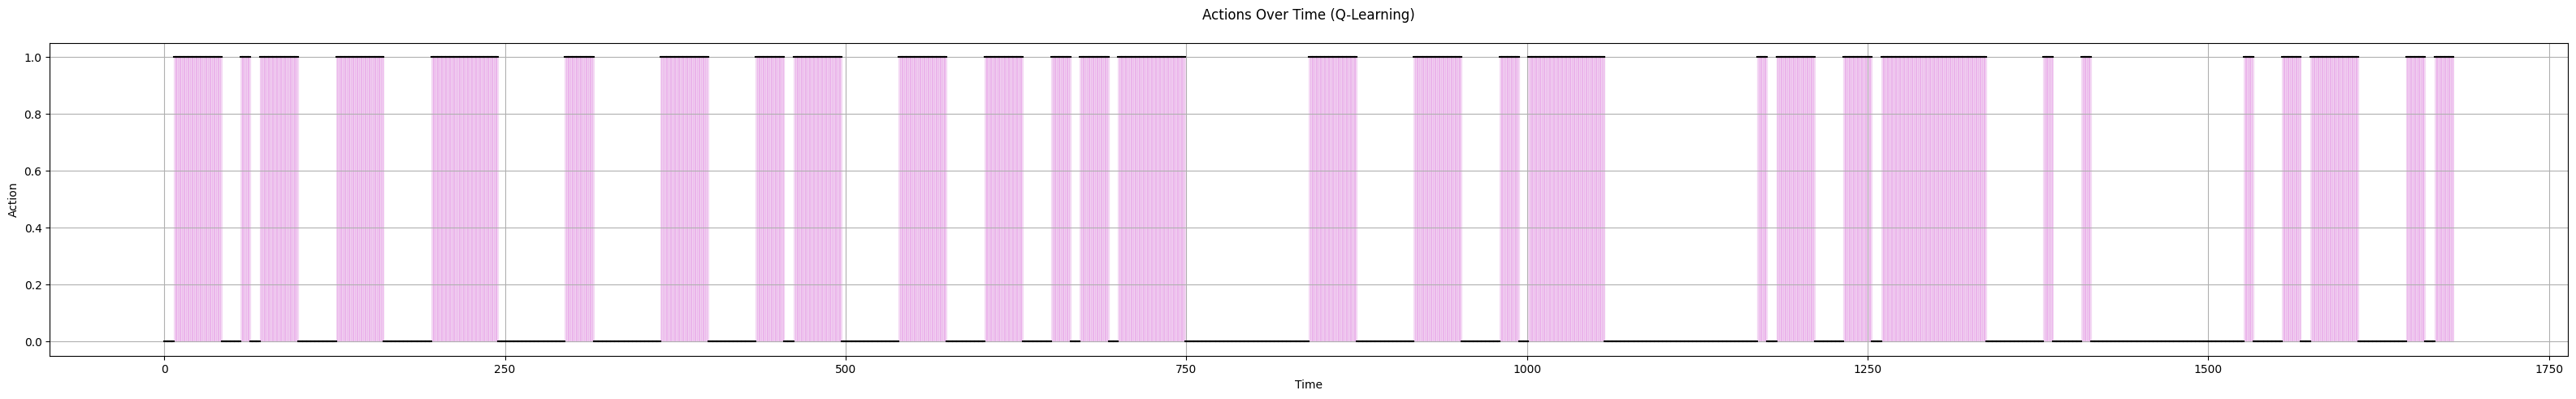

In [22]:
A_index = 0
shadow_segments = []

plt.figure(figsize=(40,5))

for act in Action_list_QL:
    if act == 'med':
        plt.plot([A_index, A_index+1], [1,1], color='black', linewidth=1.5)
        shadow_segments.append((A_index, A_index+1))
    elif act == 'non_med':
        plt.plot([A_index, A_index+1], [0,0], color='black', linewidth=1.5)
    A_index = A_index + 1

for start, end in shadow_segments:
    plt.fill_between([start, end], 0, 1, color='m', alpha=0.1)

plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Action')
plt.title('Actions Over Time (Q-Learning)\n')

plt.savefig('/Users/ekeulseuji/Downloads/Actions_QL_C3.png', dpi=600, bbox_inches='tight')
plt.show()

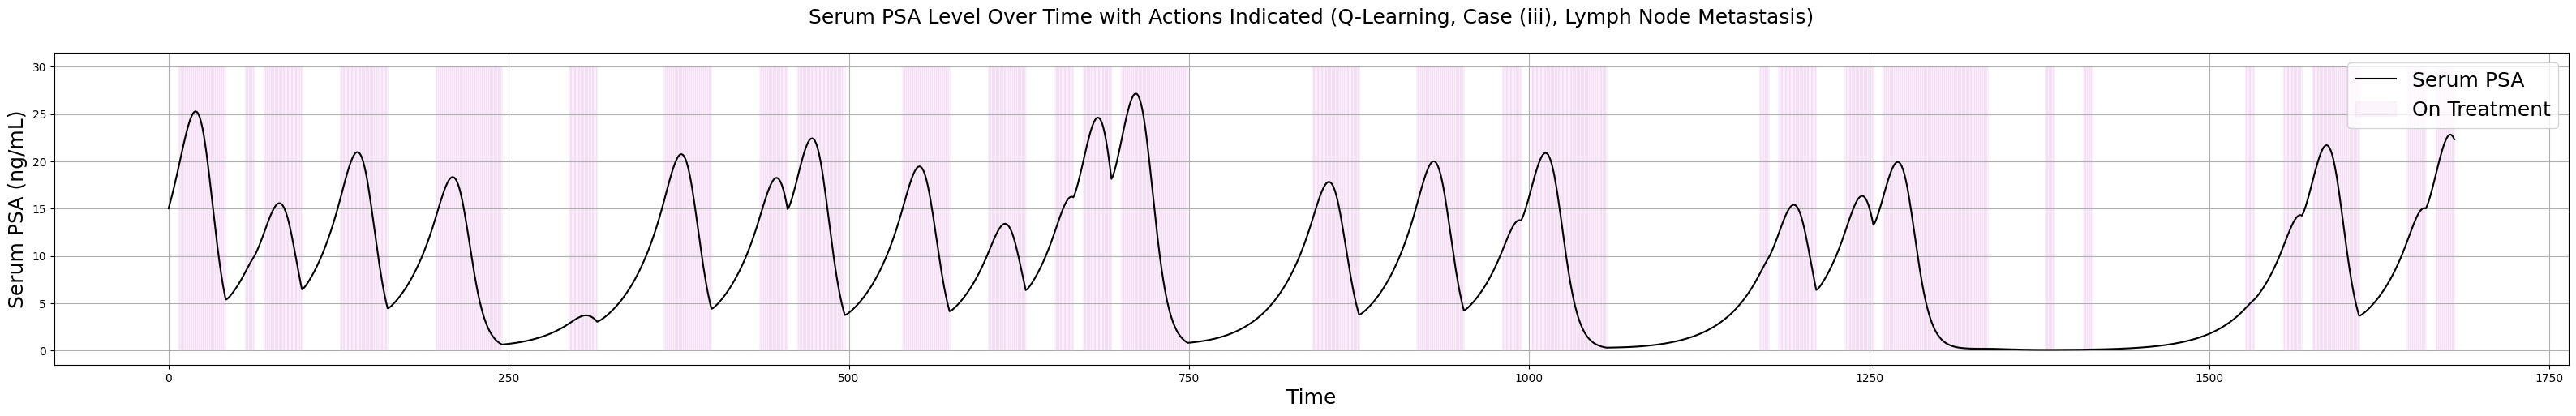

In [23]:
fixed_length = 1680

if len(PSA_List) < fixed_length:
    PSA_List_padded = PSA_List + [0] * (fixed_length - len(PSA_List))
else:
    PSA_List_padded = PSA_List[:fixed_length]

Y_index = [i for i in range(len(PSA_List_padded))]
Y_index2 = [i for i in range(len(PSA_List))]

plt.figure(figsize=(40,5))
plt.plot(Y_index, PSA_List_padded, color='black', alpha=0.0, linewidth=1.5, linestyle='-')

plt.plot(Y_index2, PSA_List, color='black', linewidth=1.5, linestyle='-', label='Serum PSA')

# plt.plot(Y_index2[-21:], PSA_List[-21:], color='crimson', linewidth=1.5, linestyle='--', label='Signifies Progression')

A_index = 0
shadow_segments = []

if len(Action_list_QL) < fixed_length:
    Action_list_QL_padded = Action_list_QL + ['0'] * (fixed_length - len(Action_list_QL))
else:
    Action_list_QL_padded = Action_list_QL[:fixed_length]

Y_index = [i for i in range(len(Action_list_QL_padded))]

for act in Action_list_QL_padded:
    if act == 'med':
        plt.plot([A_index, A_index+1], [30,30], color='m', alpha=0.01, linewidth=1.5)
        shadow_segments.append((A_index, A_index+1))
    elif act == 'non_med':
        plt.plot([A_index, A_index+1], [0,0], color='black', alpha=0.01, linewidth=1.5)
    elif act == '0':
        plt.plot([A_index, A_index+1], [0,0], color='black', alpha=0.01, linewidth=1.5)
    A_index = A_index + 1

labelled = False
for start, end in shadow_segments:
    if labelled == False:
        plt.fill_between([start, end], 0, 30, color='m', alpha=0.04, label='On Treatment')
        labelled = True
    else:
        plt.fill_between([start, end], 0, 30, color='m', alpha=0.04)

plt.grid(True)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Serum PSA (ng/mL)', fontsize=18)
plt.title('Serum PSA Level Over Time with Actions Indicated (Q-Learning, Case (iii), Lymph Node Metastasis)\n', fontsize=18)
plt.legend(fontsize=18, loc='upper right')
plt.savefig('/Users/ekeulseuji/Downloads/QL_C3_Lymph.pdf', bbox_inches='tight')
plt.show()

In [24]:
print(len(shadow_segments))

784


### **Simple ON-OFF**

In [25]:
Action_List_SO = []
STARTING_TIME = 0
Current_Action = 'med'

In [26]:
a0 = INIT[0]; x10 = INIT[1]; x20 = INIT[2]
A = [a0]; X1 = [x10]; X2 = [x20]; Y = [c1*X1[0]+c2*X2[0]]; dY = []
# P1 = [A[0]/(A[0]+k2)]; Q1 = [k3+(1-k3)*(A[0]/(A[0]+k4))]; P2 = [1-A[0]/A[0]]; Q2 = [1]; M = [m1*(1-(A[0]/A[0]))]

In [27]:
for Week in range(N_STATES//4):
    '''
    do simple switching
    '''
    if Week > 0:
        if Y[-1] > 10.0 and dY[-1] > 0.1:
            Current_Action = 'med'
        elif Y[-1] <= 5.0 and dY[-1] < 0.1:
            Current_Action = 'non_med'
        else:
            Current_Action = Current_Action

    '''
    med-/no med-induced dynamics 
    '''
    if Current_Action == 'med':
        A, X1, X2, Y, dY = On_Treatment(A, X1, X2, Y, dY, Week, a0)
    elif Current_Action == 'non_med':
        A, X1, X2, Y, dY = Off_Treatment(A, X1, X2, Y, dY, Week, a0)

    Action_List_SO.extend([Current_Action]*7)
    
    # relapse, exit the loop
    if check_biomedical_progression(Y, dY) == True:  
        print('BR. Days Reached:', Week*7)
        break;

print('Days Reached:', Week*7)

Days Reached: 1673


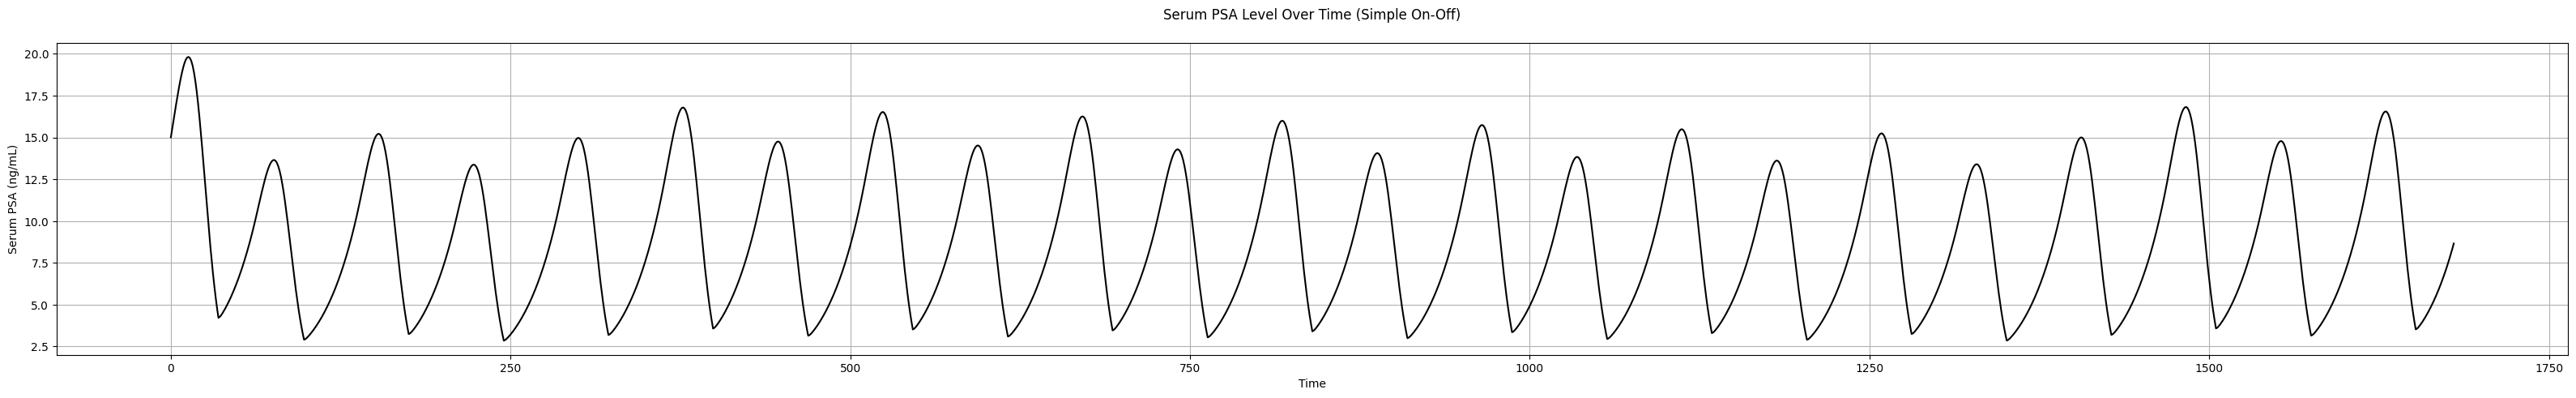

In [28]:
Y_index = [i for i in range(len(Y))]

plt.figure(figsize=(40,5))
plt.plot(Y_index, Y, label='y(t)', color='black', linewidth=1.5, linestyle='-')

plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Serum PSA (ng/mL)')
plt.title('Serum PSA Level Over Time (Simple On-Off)\n')

plt.savefig('/Users/ekeulseuji/Downloads/Serum_PSA_SO.png', dpi=600, bbox_inches='tight')
plt.show()

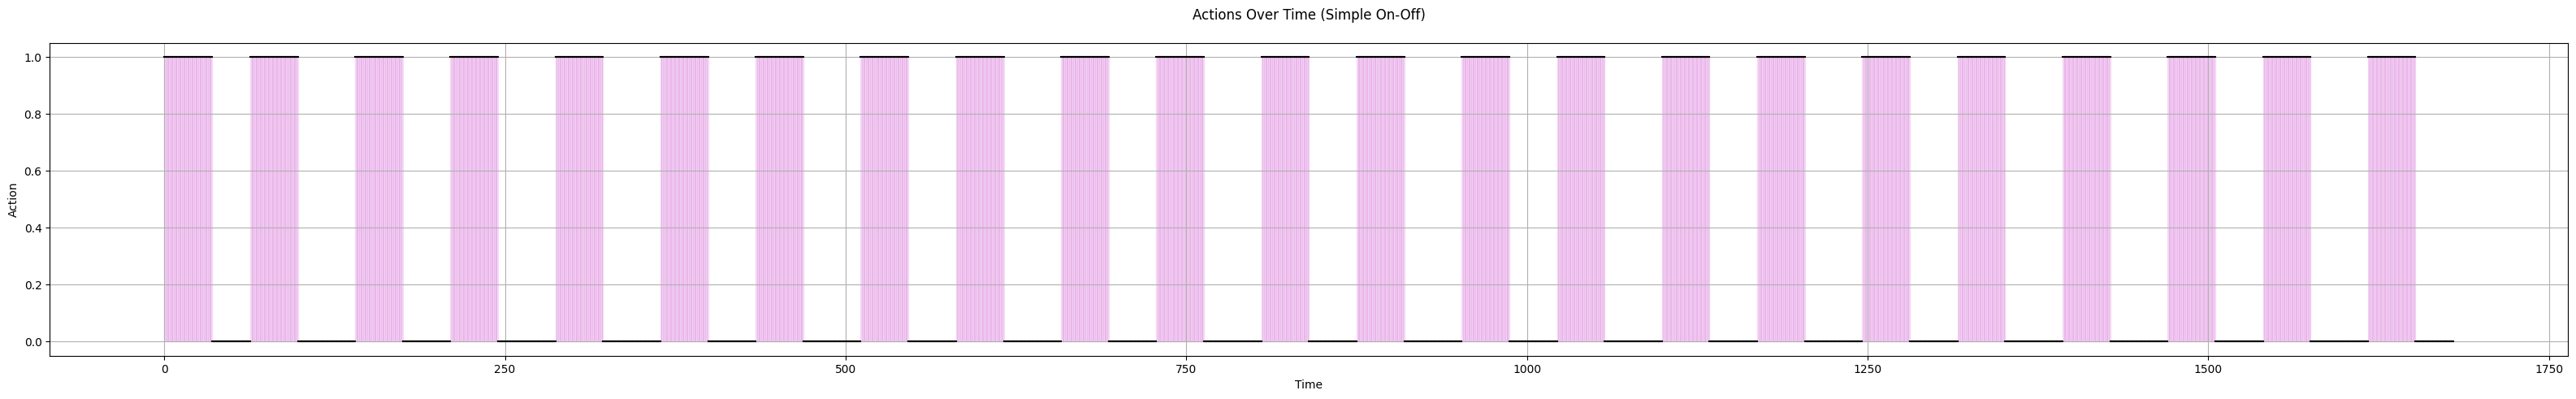

In [29]:
A_index = 0
shadow_segments = []

plt.figure(figsize=(40,5))

for act in Action_List_SO:
    if act == 'med':
        plt.plot([A_index, A_index+1], [1,1], color='black', linewidth=1.5)
        shadow_segments.append((A_index, A_index+1))
    elif act == 'non_med':
        plt.plot([A_index, A_index+1], [0,0], color='black', linewidth=1.5)
    A_index = A_index + 1

for start, end in shadow_segments:
    plt.fill_between([start, end], 0, 1, color='m', alpha=0.1)

plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Action')
plt.title('Actions Over Time (Simple On-Off)\n')

plt.savefig('/Users/ekeulseuji/Downloads/Actions_SO.png', dpi=600, bbox_inches='tight')
plt.show()

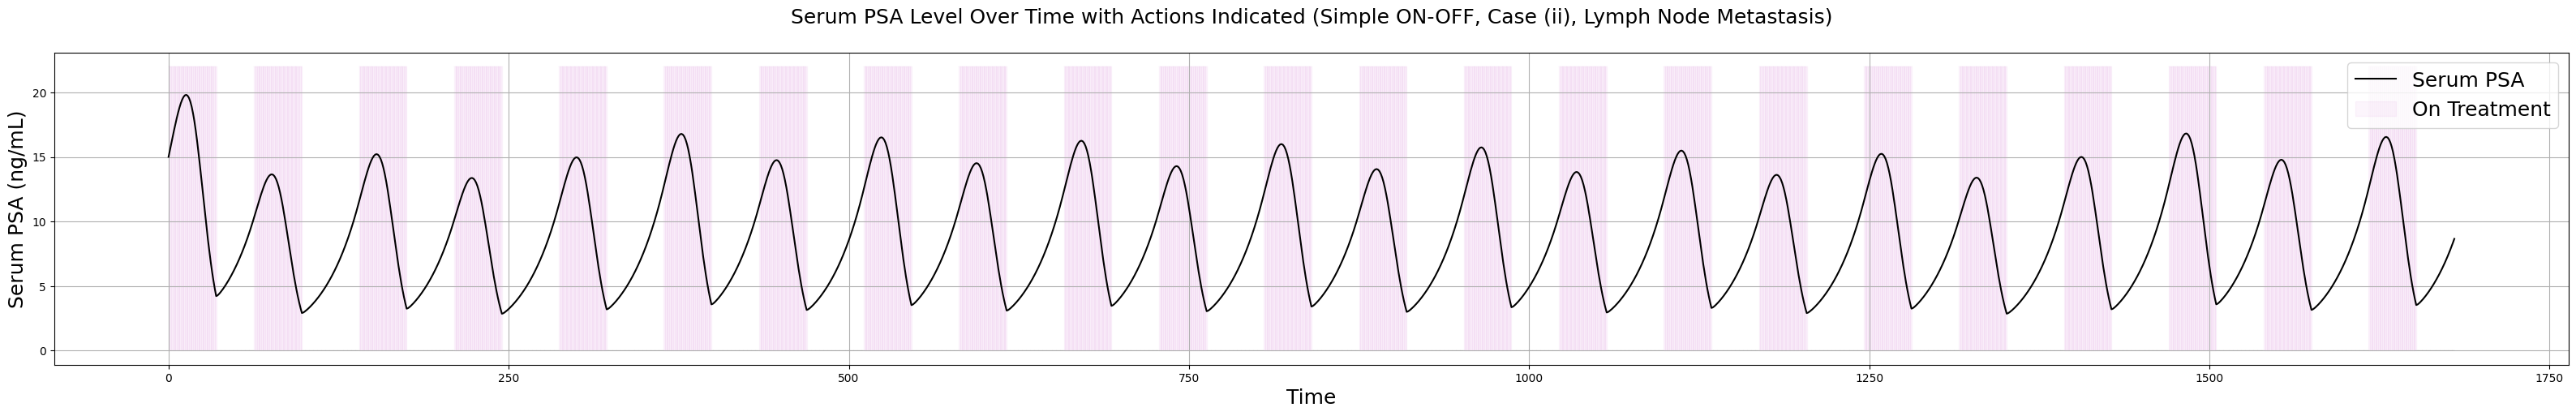

In [33]:
fixed_length = 1680

if len(Y) < fixed_length:
    Y_padded = Y + [0] * (fixed_length - len(Y))
else:
    Y_padded = Y[:fixed_length]

Y_index = [i for i in range(len(Y_padded))]
Y_index2 = [i for i in range(len(Y))]

plt.figure(figsize=(40,5))
plt.plot(Y_index, Y_padded, color='black', alpha=0.0, linewidth=1.5, linestyle='-')

plt.plot(Y_index2, Y, color='black', linewidth=1.5, linestyle='-', label='Serum PSA')

# plt.plot(Y_index2[-21:], PSA_List[-21:], color='crimson', linewidth=1.5, linestyle='--', label='Signifies Progression')

A_index = 0
shadow_segments = []

if len(Action_List_SO) < fixed_length:
    Action_List_SO_padded = Action_List_SO + ['0'] * (fixed_length - len(Action_List_SO))
else:
    Action_List_SO_padded = Action_List_SO[:fixed_length]

Y_index = [i for i in range(len(Action_List_SO_padded))]

for act in Action_List_SO_padded:
    if act == 'med':
        plt.plot([A_index, A_index+1], [22,22], color='m', alpha=0.01, linewidth=1.5)
        shadow_segments.append((A_index, A_index+1))
    elif act == 'non_med':
        plt.plot([A_index, A_index+1], [0,0], color='black', alpha=0.01, linewidth=1.5)
    elif act == '0':
        plt.plot([A_index, A_index+1], [0,0], color='black', alpha=0.01, linewidth=1.5)
    A_index = A_index + 1

labelled = False
for start, end in shadow_segments:
    if labelled == False:
        plt.fill_between([start, end], 0, 22, color='m', alpha=0.04, label='On Treatment')
        labelled = True
    else:
        plt.fill_between([start, end], 0, 22, color='m', alpha=0.04)

plt.grid(True)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Serum PSA (ng/mL)', fontsize=18)
plt.title('Serum PSA Level Over Time with Actions Indicated (Simple ON-OFF, Case (ii), Lymph Node Metastasis)\n', fontsize=18)
plt.legend(fontsize=18, loc='upper right')
plt.savefig('/Users/ekeulseuji/Downloads/SO_C3_Lymph.png', dpi=600, bbox_inches='tight')
plt.show()

In [34]:
print(len(shadow_segments))

805
